In [1]:
# Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Upload Dataset

from google.colab import files
uploaded = files.upload()

Saving feature-engineered-data.csv to feature-engineered-data.csv


In [3]:
# Load Dataset

df = pd.read_csv("feature-engineered-data.csv")
df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Attrition
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746,1
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241,0
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746,1
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746,0
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241,0


In [4]:
# Split Features and Target

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Train-test split (80-20) with stratification for imbalance

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# Handle Class Imbalance

print("Original class distribution:")
print(y_train.value_counts())
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("\nResampled class distribution:")
print(pd.Series(y_train_res).value_counts())

Original class distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Resampled class distribution:
Attrition
0    986
1    986
Name: count, dtype: int64


In [6]:
# Initialize Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)}

In [7]:
# Define Hyperparameter Grids

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5, 10]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2]
    }
}

In [8]:
# Cross-Validation & Hyperparameter Tuning

best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    print(f"\n{name} - Hyperparameter tuning")
    grid = GridSearchCV(model, param_grids[name], cv=cv, scoring="recall", n_jobs=-1)
    grid.fit(X_train_res, y_train_res)
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV Recall: {grid.best_score_:.4f}")
    best_models[name] = grid.best_estimator_


Logistic Regression - Hyperparameter tuning
Best params: {'C': 10, 'solver': 'lbfgs'}
Best CV Recall: 0.8205

Random Forest - Hyperparameter tuning
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall: 0.9168

XGBoost - Hyperparameter tuning
Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}
Best CV Recall: 0.9097


In [9]:
# Decision Tree & LightGBM

from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
extra_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}
extra_param_grids = {
    "Decision Tree": {
        "max_depth": [3,5,10,None],
        "min_samples_split": [2,5,10]
    },

    "LightGBM": {
        "n_estimators": [100,200],
        "learning_rate": [0.01,0.1],
        "max_depth": [-1,5,10]
    }
}

In [10]:
# Tuning These Additional Models

for name, model in extra_models.items():
    print(f"\n{name} - Hyperparameter tuning")
    grid = GridSearchCV(
        model,
        extra_param_grids[name],
        cv=cv,
        scoring="recall",
        n_jobs=-1
    )
    grid.fit(X_train_res, y_train_res)
    print("Best Params:", grid.best_params_)
    print("Best CV Recall:", grid.best_score_)
    best_models[name] = grid.best_estimator_


Decision Tree - Hyperparameter tuning
Best Params: {'max_depth': None, 'min_samples_split': 2}
Best CV Recall: 0.8753012357073271

LightGBM - Hyperparameter tuning
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 986, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001899 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7762
[LightGBM] [Info] Number of data points in the train set: 1972, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200}
Best CV Recall: 0.9056811772547814


In [11]:
# Evaluate All Models

from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report
evaluation_results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Recall": rec
    })
    print(f"{name} Evaluation")
    print("Accuracy:", acc)
    print("Recall:", rec)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression Evaluation
Accuracy: 0.782312925170068
Recall: 0.574468085106383

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       247
           1       0.38      0.57      0.46        47

    accuracy                           0.78       294
   macro avg       0.65      0.70      0.66       294
weighted avg       0.83      0.78      0.80       294

Random Forest Evaluation
Accuracy: 0.8469387755102041
Recall: 0.2765957446808511

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.54      0.28      0.37        47

    accuracy                           0.85       294
   macro avg       0.71      0.62      0.64       294
weighted avg       0.82      0.85      0.83       294

XGBoost Evaluation
Accuracy: 0.8571428571428571
Recall: 0.3191489361702128

Classification Report:
              precision    recall

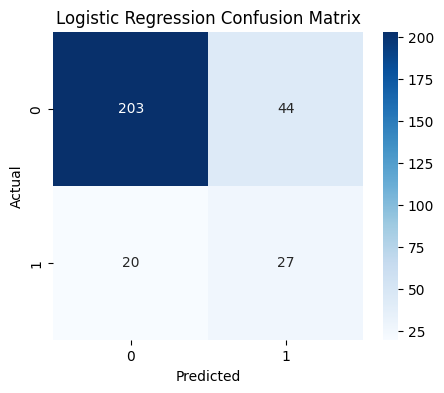

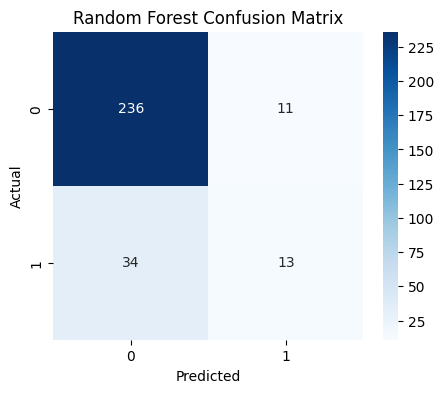

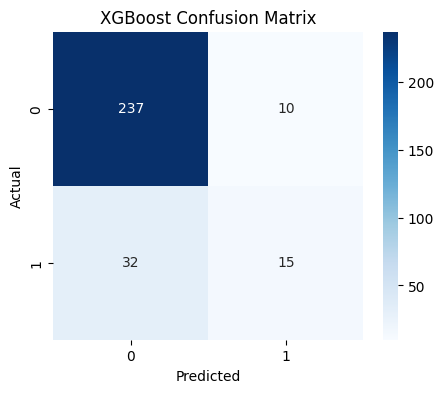

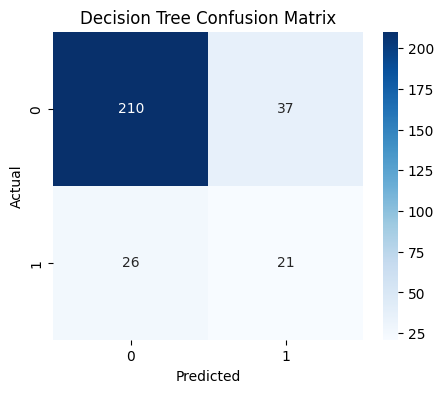

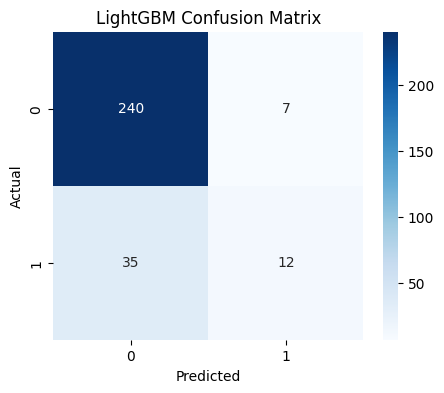

In [12]:
# Confusion Matrix for Each Model

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

In [13]:
# Model Comparison Table

results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(by="Recall", ascending=False)
results_df

,Model,Accuracy,Recall
0,Logistic Regression,0.782313,0.574468
3,Decision Tree,0.785714,0.446809
2,XGBoost,0.857143,0.319149
1,Random Forest,0.846939,0.276596
4,LightGBM,0.857143,0.255319


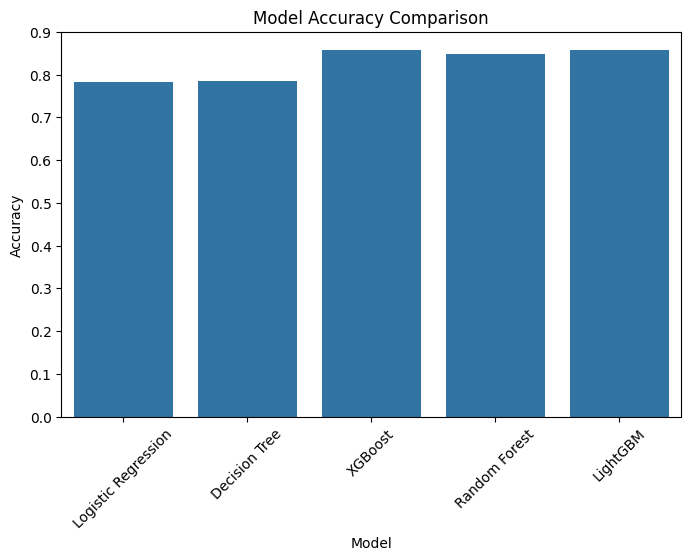

In [14]:
# Visualize Model Performance For Accuracy comparison

plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

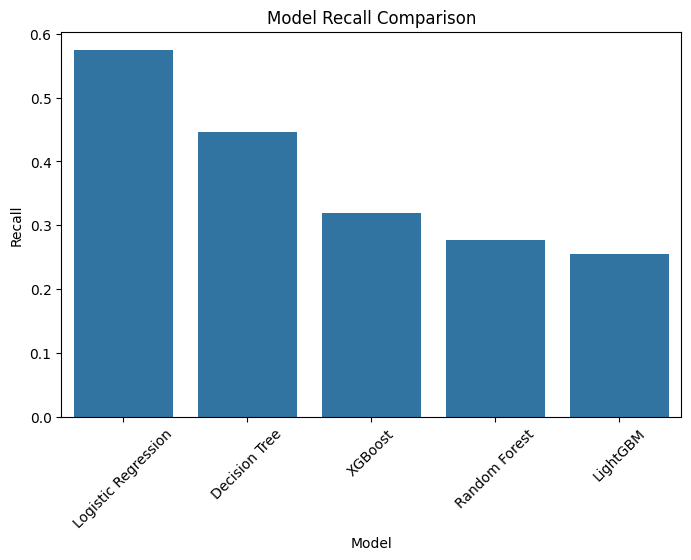

In [15]:
# Visualize Model Performance For Recall comparison

plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Recall")
plt.title("Model Recall Comparison")
plt.xticks(rotation=45)
plt.show()

In [16]:
# Identify the Best Model

best_model_name = results_df.iloc[0]["Model"]
print("Best model based on Recall:", best_model_name)
best_model = best_models[best_model_name]

Best model based on Recall: Logistic Regression


In [17]:
# Install joblib

!pip install joblib

In [18]:
# Import joblib

import joblib

In [20]:
# Save all best models

best_models
joblib.dump(best_models["Logistic Regression"], "logistic_regression.pkl")
joblib.dump(best_models["Decision Tree"], "decision_tree.pkl")
joblib.dump(best_models["Random Forest"], "random_forest.pkl")
joblib.dump(best_models["XGBoost"], "xgboost.pkl")
joblib.dump(best_models["LightGBM"], "lightgbm.pkl")
print("All models saved successfully.")

All models saved successfully.


In [21]:
# Download the models

from google.colab import files
files.download("logistic_regression.pkl")
files.download("decision_tree.pkl")
files.download("random_forest.pkl")
files.download("xgboost.pkl")
files.download("lightgbm.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>